In [211]:
# Imports & Data load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ai_jobs = pd.read_csv("03_ai_jobs_market_2025_2026.csv")
cities = pd.read_csv("03_Top 100 Worlds Largest Cities.csv")
tech_jobs = pd.read_csv("03_global_ai_jobs.csv")

In [212]:
# Head
print("AI Jobs:")
ai_jobs.info()
print(ai_jobs.head(), "\n")

print("Tech Jobs:")
tech_jobs.info()
print(tech_jobs.head(), "\n")

print("Cities:")
cities.info()
print(cities.head())

AI Jobs:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 


In [213]:
# Description
ai_jobs.info()
cities.info()
tech_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [214]:
# Show columns
ai_jobs.columns
tech_jobs.columns
cities.columns

Index(['Rank', 'City', 'Country', 'Population (Est.)', 'Area (sq km)'], dtype='object')

In [215]:
print(ai_jobs.columns)
print(tech_jobs.columns)
print(cities.columns)

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier'],
      dtype='object')
Index(['id', 'country', 'job_role', 'ai_specialization', 'experience_level',
       'experience_years', 'salary_usd', 'bonus_usd', 'education_required',
       'industry', 'company_size', 'interview_rounds', 'year', 'work_mode',
       'weekly_hours', 'company_rating', 'job_openings',
       'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score',
       'company_funding_billion', 'economic_index', 'ai_maturity_years',
       'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days',
   

In [216]:
# 1️⃣ Spalten vereinheitlichen und umbenennen

# AI-Jobs
ai_jobs.rename(columns={
    'years_of_experience': 'experience_years',
    'annual_salary_usd': 'salary_usd'
}, inplace=True)
# Optional: eindeutige Spaltennamen für Merge
ai_jobs['salary_usd_ai'] = ai_jobs['salary_usd']
ai_jobs['experience_years_ai'] = ai_jobs['experience_years']

# Tech-Jobs
tech_jobs.rename(columns={
    'salary_usd': 'salary_usd'
}, inplace=True)
tech_jobs['salary_usd_tech'] = tech_jobs['salary_usd']
tech_jobs['experience_years_tech'] = tech_jobs['experience_years']

# Städte-Daten
cities.rename(columns={
    'Country': 'country',
    'Population (Est.)': 'population',
    'Area (sq km)': 'area_km2'
}, inplace=True)

# Kommas entfernen und in Float umwandeln
cities['population'] = cities['population'].replace(',', '', regex=True).astype(float)
cities['area_km2'] = cities['area_km2'].replace(',', '', regex=True).astype(float)

# 2️⃣ Aggregation der Daten

# AI-Jobs pro Land
ai_agg = ai_jobs.groupby('country').agg({
    'salary_usd_ai': 'mean',
    'experience_years_ai': 'mean'
}).reset_index()

# Tech-Jobs pro Land
tech_agg = tech_jobs.groupby('country').agg({
    'salary_usd_tech': 'mean',
    'experience_years_tech': 'mean'
}).reset_index()

# Städte pro Land
cities_agg = cities.groupby('country').agg({
    'population': 'sum',
    'area_km2': 'sum'
}).reset_index()

# 3️⃣ Alle Aggregationen zusammenführen
df = ai_agg.merge(tech_agg, on='country', how='outer') \
           .merge(cities_agg, on='country', how='left')

# 4️⃣ Ergebnis prüfen
print(df.head())

     country  salary_usd_ai  experience_years_ai  salary_usd_tech  \
0  Australia  188000.000000             6.333333    110549.808802   
1     Brazil            NaN                  NaN     53704.839231   
2     Canada  180588.235294             6.635294    108671.052618   
3      China  134287.356322             6.022989              NaN   
4     France  183151.515152             6.287879     95170.457796   

   experience_years_tech   population  area_km2  
0               7.039531   10780000.0   22359.0  
1               7.125116   48750000.0    5571.0  
2               6.951066    6550000.0     630.0  
3                    NaN  237065000.0   34654.0  
4               6.975134   11420000.0    2723.0  


In [217]:
# Erste Zeilen prüfen
print(df.head())

# Grundlegende Statistik
print(df.describe())

# Datentypen und Nullwerte checken
print(df.info())
print(df.isna().sum())

     country  salary_usd_ai  experience_years_ai  salary_usd_tech  \
0  Australia  188000.000000             6.333333    110549.808802   
1     Brazil            NaN                  NaN     53704.839231   
2     Canada  180588.235294             6.635294    108671.052618   
3      China  134287.356322             6.022989              NaN   
4     France  183151.515152             6.287879     95170.457796   

   experience_years_tech   population  area_km2  
0               7.039531   10780000.0   22359.0  
1               7.125116   48750000.0    5571.0  
2               6.951066    6550000.0     630.0  
3                    NaN  237065000.0   34654.0  
4               6.975134   11420000.0    2723.0  
       salary_usd_ai  experience_years_ai  salary_usd_tech  \
count      14.000000            14.000000        12.000000   
mean   181517.545988             6.236128     96531.735096   
std     25824.797056             0.298718     25008.671901   
min    133122.807018             5.76

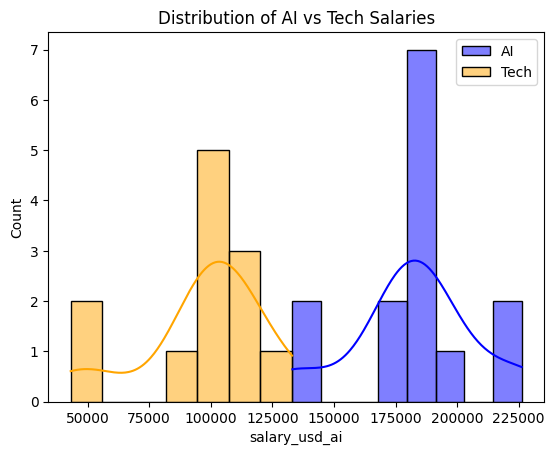

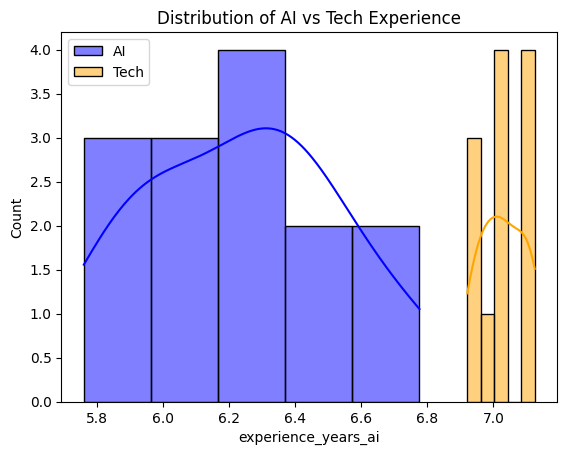

In [218]:
import seaborn as sns
import matplotlib.pyplot as plt

# AI vs Tech Gehälter
sns.histplot(df['salary_usd_ai'], kde=True, color='blue', label='AI')
sns.histplot(df['salary_usd_tech'], kde=True, color='orange', label='Tech')
plt.legend()
plt.title('Distribution of AI vs Tech Salaries')
plt.show()

# Erfahrung
sns.histplot(df['experience_years_ai'], kde=True, color='blue', label='AI')
sns.histplot(df['experience_years_tech'], kde=True, color='orange', label='Tech')
plt.legend()
plt.title('Distribution of AI vs Tech Experience')
plt.show()

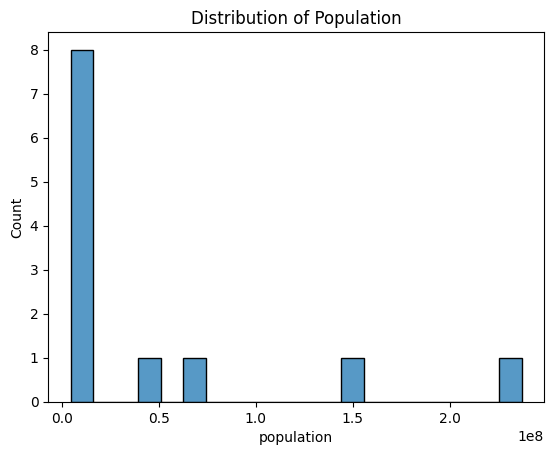

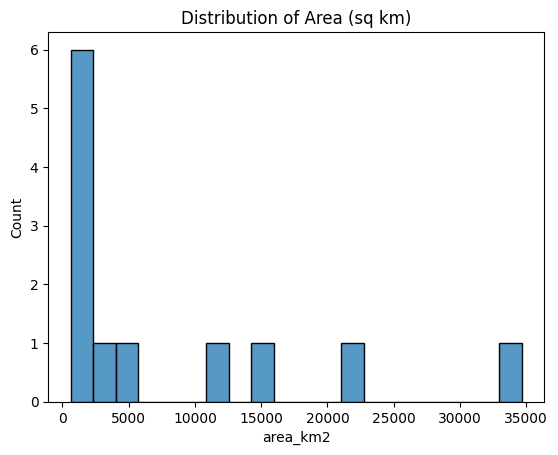

In [219]:
sns.histplot(df['population'], bins=20)
plt.title('Distribution of Population')
plt.show()

sns.histplot(df['area_km2'], bins=20)
plt.title('Distribution of Area (sq km)')
plt.show()

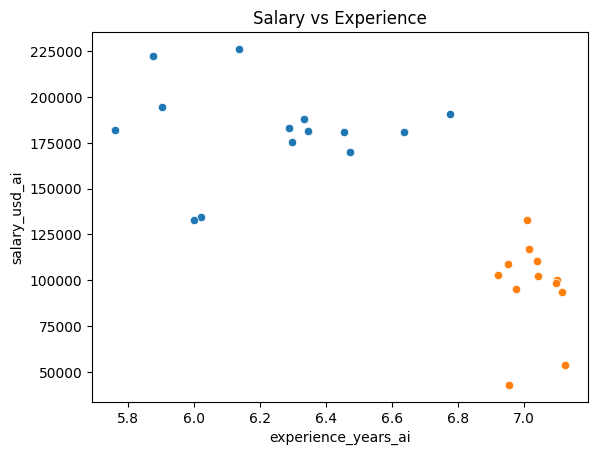

In [220]:
sns.scatterplot(data=df, x='experience_years_ai', y='salary_usd_ai')
sns.scatterplot(data=df, x='experience_years_tech', y='salary_usd_tech')
plt.title('Salary vs Experience')
plt.show()

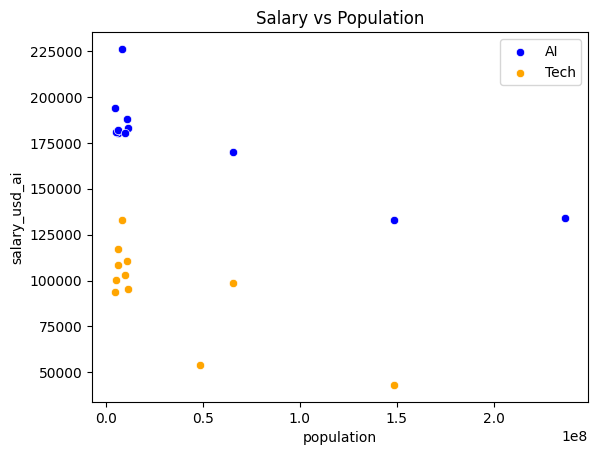

In [221]:
sns.scatterplot(data=df, x='population', y='salary_usd_ai', color='blue', label='AI')
sns.scatterplot(data=df, x='population', y='salary_usd_tech', color='orange', label='Tech')
plt.title('Salary vs Population')
plt.legend()
plt.show()

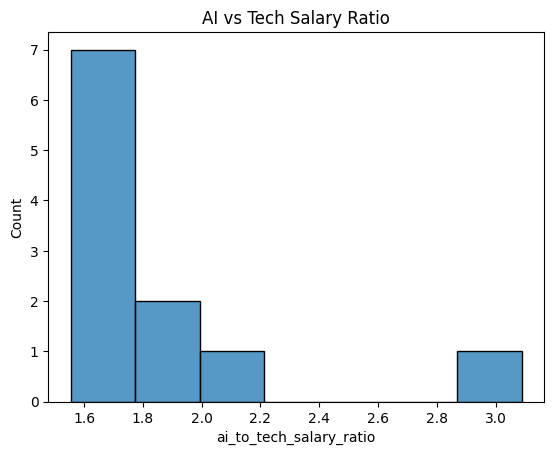

In [222]:
df['ai_to_tech_salary_ratio'] = df['salary_usd_ai'] / df['salary_usd_tech']
sns.histplot(df['ai_to_tech_salary_ratio'].dropna())
plt.title('AI vs Tech Salary Ratio')
plt.show()

In [223]:
# Allgemeiner Überblick
print(df.info())
print(df.describe())

# Fehlende Werte prüfen
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  15 non-null     object 
 1   salary_usd_ai            14 non-null     float64
 2   experience_years_ai      14 non-null     float64
 3   salary_usd_tech          12 non-null     float64
 4   experience_years_tech    12 non-null     float64
 5   population               12 non-null     float64
 6   area_km2                 12 non-null     float64
 7   ai_to_tech_salary_ratio  11 non-null     float64
dtypes: float64(7), object(1)
memory usage: 1.1+ KB
None
       salary_usd_ai  experience_years_ai  salary_usd_tech  \
count      14.000000            14.000000        12.000000   
mean   181517.545988             6.236128     96531.735096   
std     25824.797056             0.298718     25008.671901   
min    133122.807018             5.760563     43106.2

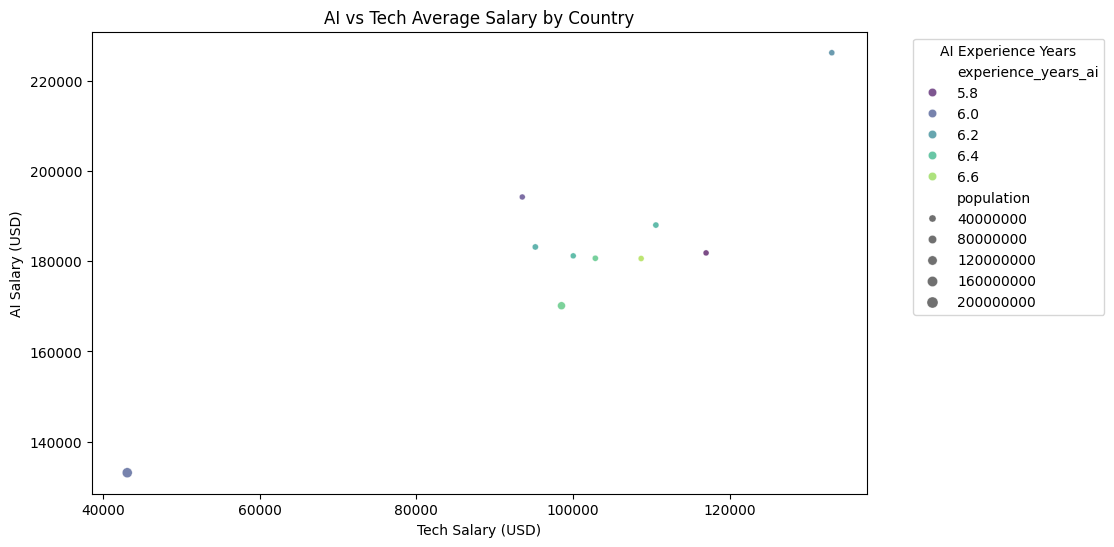

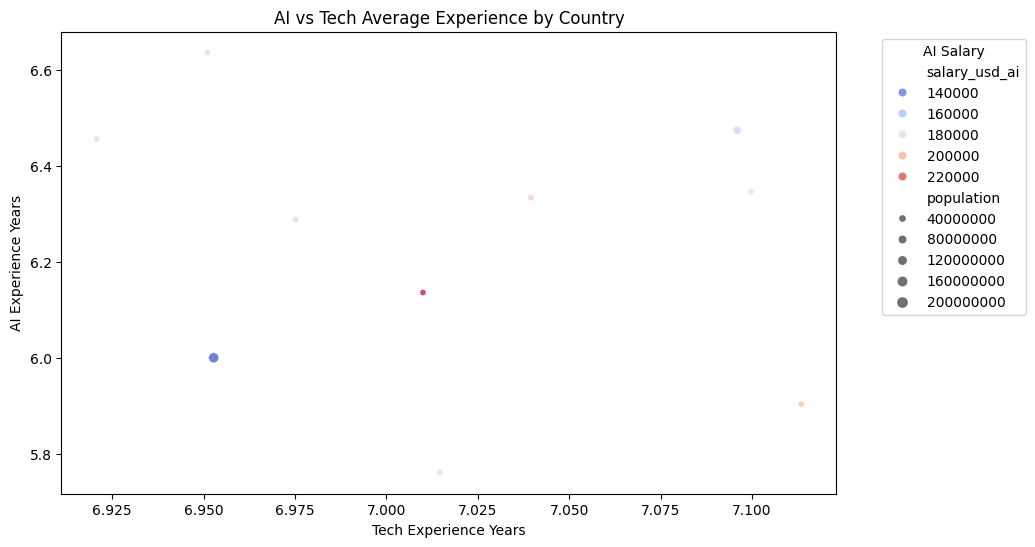

In [224]:
# AI vs Tech Gehalt vergleichen
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='salary_usd_tech', y='salary_usd_ai', size='population', hue='experience_years_ai', alpha=0.7, palette='viridis')
plt.title('AI vs Tech Average Salary by Country')
plt.xlabel('Tech Salary (USD)')
plt.ylabel('AI Salary (USD)')
plt.legend(title='AI Experience Years', bbox_to_anchor=(1.05, 1))
plt.show()

# Erfahrung AI vs Tech
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='experience_years_tech', y='experience_years_ai', size='population', hue='salary_usd_ai', alpha=0.7, palette='coolwarm')
plt.title('AI vs Tech Average Experience by Country')
plt.xlabel('Tech Experience Years')
plt.ylabel('AI Experience Years')
plt.legend(title='AI Salary', bbox_to_anchor=(1.05, 1))
plt.show()

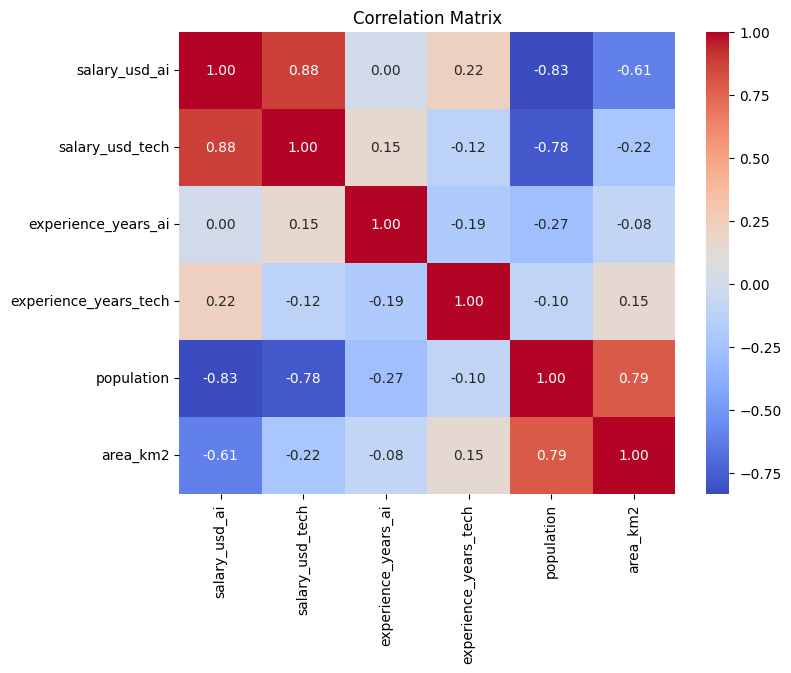

In [225]:
# Nur relevante numerische Spalten
num_cols = ['salary_usd_ai', 'salary_usd_tech', 'experience_years_ai', 'experience_years_tech', 'population', 'area_km2']

# Korrelationsmatrix
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

        country  ai_tech_salary_ratio
7         India              3.088245
12          UAE              2.077110
4        France              1.924458
5       Germany              1.811661
13           UK              1.756793
8         Japan              1.727090
9   Netherlands              1.711842
14          USA              1.700737
0     Australia              1.700591
2        Canada              1.661788


C:\Users\kasum\AppData\Local\Temp\ipykernel_8896\3529553482.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




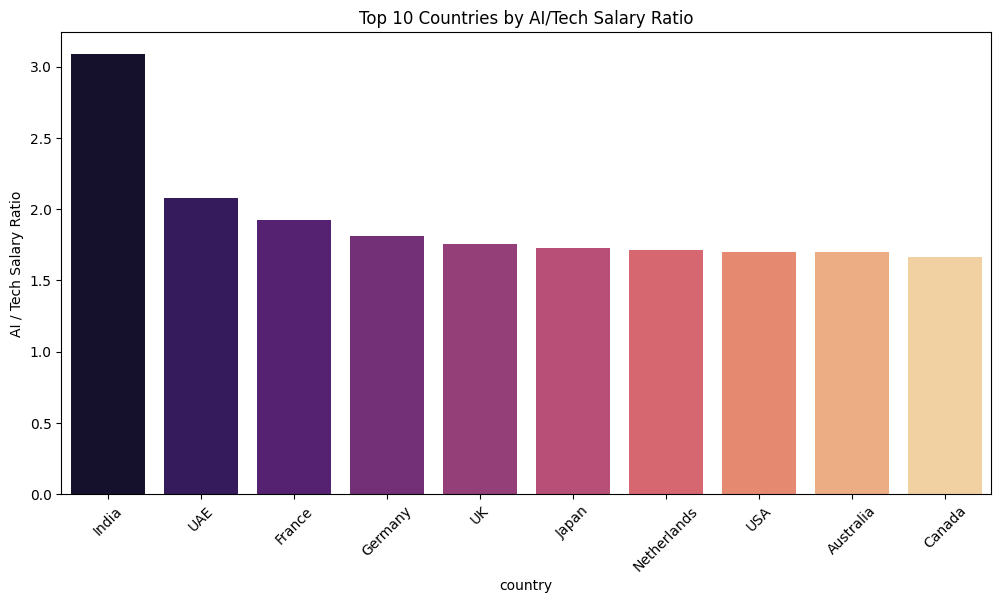

In [226]:
# Neue Spalte
df['ai_tech_salary_ratio'] = df['salary_usd_ai'] / df['salary_usd_tech']

# Länder mit höchstem Verhältnis
print(df[['country', 'ai_tech_salary_ratio']].sort_values(by='ai_tech_salary_ratio', ascending=False).head(10))

# Visualisierung
plt.figure(figsize=(12,6))
sns.barplot(data=df.sort_values('ai_tech_salary_ratio', ascending=False).head(10), x='country', y='ai_tech_salary_ratio', palette='magma')
plt.xticks(rotation=45)
plt.title('Top 10 Countries by AI/Tech Salary Ratio')
plt.ylabel('AI / Tech Salary Ratio')
plt.show()

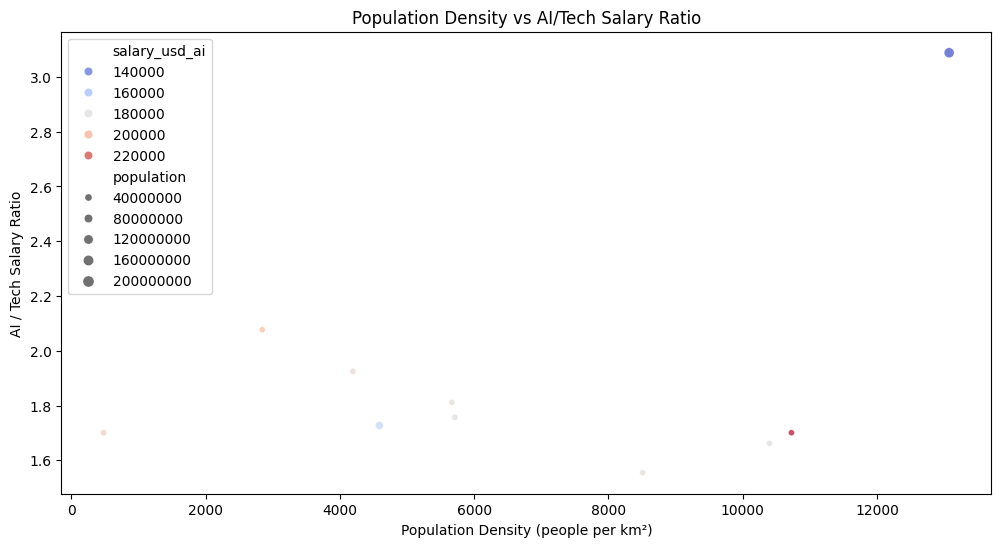

In [227]:
df['population_density'] = df['population'] / df['area_km2']

plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='population_density', y='ai_tech_salary_ratio', size='population', hue='salary_usd_ai', palette='coolwarm', alpha=0.7)
plt.title('Population Density vs AI/Tech Salary Ratio')
plt.xlabel('Population Density (people per km²)')
plt.ylabel('AI / Tech Salary Ratio')
plt.show()

In [228]:
import plotly.express as px

# AI Salary Choropleth
fig_ai = px.choropleth(
    df,
    locations="country",
    locationmode="country names",  # wichtig: Länder sollten genau stimmen
    color="salary_usd_ai",
    hover_name="country",
    hover_data={
        "salary_usd_ai": ':.0f',
        "salary_usd_tech": ':.0f',
        "experience_years_ai": ':.2f',
        "experience_years_tech": ':.2f'
    },
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Average AI Salary by Country (USD)"
)

fig_ai.show()

C:\Users\kasum\AppData\Local\Temp\ipykernel_8896\960658383.py:4: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [229]:
fig_tech = px.choropleth(
    df,
    locations="country",
    locationmode="country names",
    color="salary_usd_tech",
    hover_name="country",
    hover_data={
        "salary_usd_ai": ':.0f',
        "salary_usd_tech": ':.0f',
        "experience_years_ai": ':.2f',
        "experience_years_tech": ':.2f'
    },
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Average Tech Salary by Country (USD)"
)

fig_tech.show()

C:\Users\kasum\AppData\Local\Temp\ipykernel_8896\3919368105.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [230]:
fig_ratio = px.choropleth(
    df,
    locations="country",
    locationmode="country names",
    color="ai_tech_salary_ratio",
    hover_name="country",
    hover_data={
        "salary_usd_ai": ':.0f',
        "salary_usd_tech": ':.0f',
        "ai_tech_salary_ratio": ':.2f'
    },
    color_continuous_scale=px.colors.sequential.Cividis,
    title="AI / Tech Salary Ratio by Country"
)

fig_ratio.show()

C:\Users\kasum\AppData\Local\Temp\ipykernel_8896\4163837958.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [233]:
# Entferne Zeilen mit NaN in Features oder Zielvariable
df_model = df.dropna(subset=['salary_usd_tech', 'experience_years_tech', 'experience_years_ai', 'population', 'area_km2'])

X = df_model[features]
y = df_model['salary_usd_tech']

In [235]:
# Median-Imputation für Features
df[features] = df[features].fillna(df[features].median())
df['salary_usd_tech'] = df['salary_usd_tech'].fillna(df['salary_usd_tech'].median())

In [236]:
print(df[features + ['salary_usd_tech']].isna().sum())

experience_years_tech    0
experience_years_ai      0
population               0
area_km2                 0
salary_usd_tech          0
dtype: int64


In [239]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features & Ziel
features = ['experience_years_tech', 'experience_years_ai', 'population', 'area_km2']

# NaNs entfernen
df_model = df.dropna(subset=features + ['salary_usd_tech'])

X = df_model[features]
y = df_model['salary_usd_tech']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Performance manuell berechnen
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # <-- RMSE manuell
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 9239.58
R²: -3.93
